In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
# all_data = pd.read_csv('all_group_result.csv', header=0)
# read xlsx file
all_data = pd.read_excel('TENDENCY_all_group_result2_echo.xlsx', header=0, sheet_name='all_group_result2', engine='openpyxl')
print(all_data.columns)

param_list = ['ave_1', 'ave_10', 'ave_20', 'ave_25', 'ave_f1', 'ave_f3', 'acc_ave_1', 'acc_ave_10', 'acc_ave_25'] # 9 个 param
param_list = ['ave_1', 'ave_25', 'ave_f1', 'ave_f3', 'acc_ave_1', 'acc_ave_25', 'echo_rate'] # 6 个 param (best selected) + echo_rate

group_list = all_data['group3'].unique()
# sort string in group_list
group_list = sorted(group_list)

stimuli_list = all_data['stimuli'].unique()
bodypart_list = all_data['bodypart'].unique()
print(group_list)
print(stimuli_list)
print(bodypart_list)

Index(['group', 'group2', 'group3', 'stimuli', 'bat', 'bodypart', 'echo_rate',
       'ave_1', 'ave_10', 'ave_20', 'ave_25', 'ave_f1', 'ave_f3', 'acc_ave_1',
       'acc_ave_10', 'acc_ave_25', 'qua1', 'qua2', 'qua3', 'qua4', 'qua23',
       'qua14', 'qua14_rate', 'qua13_rate', 'qua12_rate', 'up', 'down', 'left',
       'right', 'up_left', 'up_right', 'down_left', 'down_right', 'left_all',
       'right_all', 'up_all', 'down_all', 'right_all_rate', 'ld_ru_rate',
       'up_all_rate'],
      dtype='object')
['a_syl2', 'b_syl2', 'c_rep', 'd_rep', 'e_rep2', 'f_rep2', 'g_comb', 'h_comb', 'i_order', 'j_order', 'k_syl1', 'l_syl1']
['NB-SFM/SFM/SFM' 'NB-SFM/SFM/NB-SFM' 'NB-SFM/SFM' 'SFM/NB-SFM'
 'NB-SFM/SFM/SFM/NB-SFM/SFM/SFM' 'NB-DFM222' 'NB-DFM555' 'NB-DFM/SFM'
 'BNBl/NB-DFM' 'BNBl/NB-SFM']
['right_arm' 'mouth' 'right_ear' 'left_arm']


[0.4, 0.88, 0.9, 1.12, 0.47, 0.64, 1.98, 2.28, 0.54, 1.3, 0.52, 2.4]
[0.4, 0.88, 0.9, 1.07, 0.51, 0.67, 2.07, 2.39, 0.55, 1.33, 0.53, 2.4]
[0.67, 1.76, 1.71, 0.4, 0.66, 0.87, 2.4, 1.8, 0.41, 0.4, 0.41, 2.3]
[0.48, 0.97, 0.97, 0.51, 0.4, 0.41, 2.3, 2.4, 0.44, 0.58, 0.44, 1.64]
[0.42, 0.85, 0.86, 0.93, 0.48, 0.79, 2.06, 2.4, 0.42, 1.26, 0.4, 2.14]
[0.4, 0.84, 0.84, 1.29, 0.77, 0.99, 2.18, 2.4, 0.7, 1.73, 0.7, 2.25]
[2.18, 2.4, 2.4, 1.51, 1.18, 0.4, 1.18, 1.9, 0.9, 1.34, 0.9, 2.23]


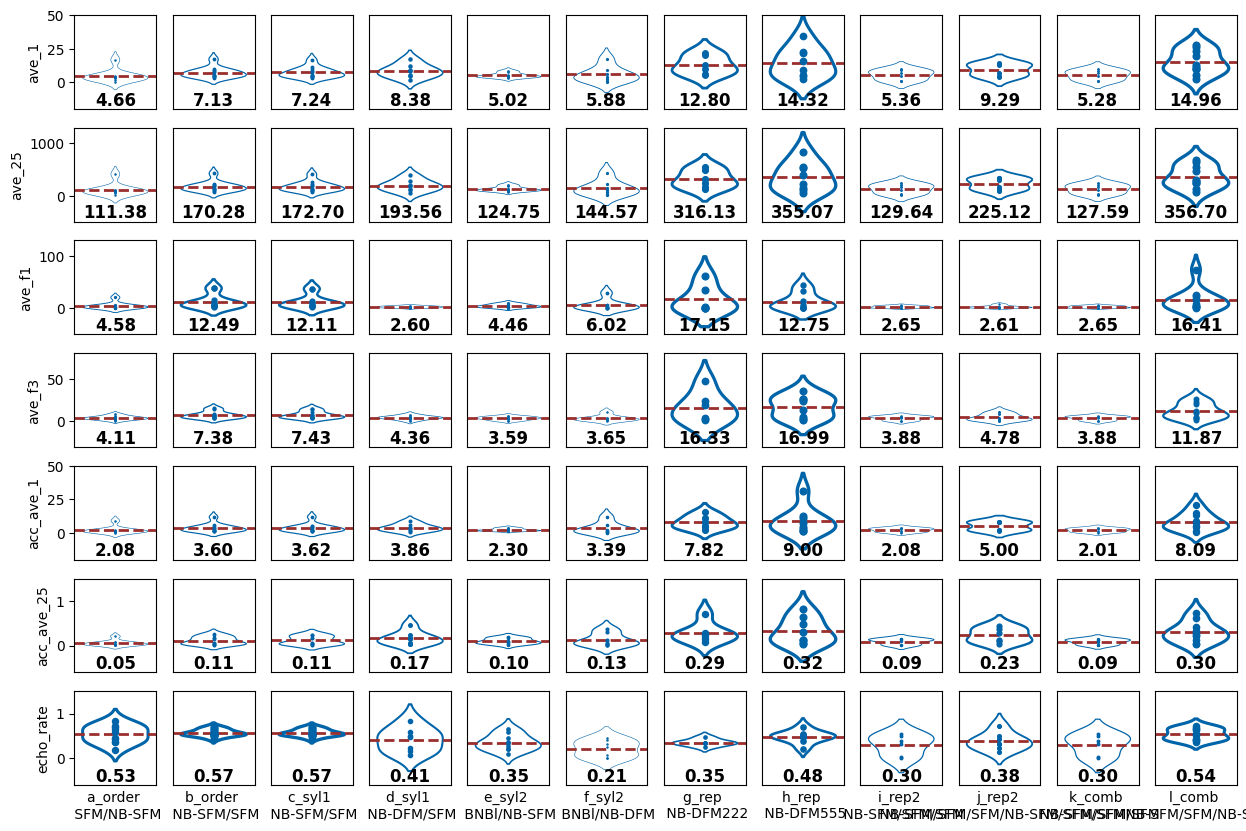

In [ ]:

# only use data of [right arm], since it occurs in all groups
plt.figure(108, figsize=(15, 10))
# p_i = 0
f_i = 0

for param in param_list:
    # p_i += 1
    average_param_list = []
    
    if param == 'ave_1':
        ylim = [-20, 50]
        scaled_param_list = [0.4, 0.88, 0.9, 1.12, 0.47, 0.64, 1.98, 2.28, 0.54, 1.3, 0.52, 2.4]
    elif param == 'ave_10':
        ylim = [-50, 400]
    elif param == 'ave_20':
        ylim = [-100, 700]
    elif param == 'ave_25':
        ylim = [-500, 1300]
        scaled_param_list = [0.4, 0.88, 0.9, 1.07, 0.51, 0.67, 2.07, 2.39, 0.55, 1.33, 0.53, 2.4]
    elif param == 'ave_f1':
        ylim = [-50, 130]
        scaled_param_list = [0.67, 1.76, 1.71, 0.4, 0.66, 0.87, 2.4, 1.8, 0.41, 0.4, 0.41, 2.3]
    elif param == 'ave_f3':
        ylim = [-30, 80]
        scaled_param_list = [0.48, 0.97, 0.97, 0.51, 0.4, 0.41, 2.3, 2.4, 0.44, 0.58, 0.44, 1.64]
    elif param == 'acc_ave_1':
        ylim = [-20, 50]
        scaled_param_list = [0.42, 0.85, 0.86, 0.93, 0.48, 0.79, 2.06, 2.4, 0.42, 1.26, 0.4, 2.14]
    elif param == 'acc_ave_10':
        ylim = [-1, 2]
    elif param == 'acc_ave_25':
        ylim = [-0.6, 1.5]
        scaled_param_list = [0.4, 0.84, 0.84, 1.29, 0.77, 0.99, 2.18, 2.4, 0.7, 1.73, 0.7, 2.25]
    elif param == 'echo_rate':
        # ylim = [0, ]
        scaled_param_list = [2.18, 2.4, 2.4, 1.51, 1.18, 0.4, 1.18, 1.9, 0.9, 1.34, 0.9, 2.23]

    
    sti_i = -1
    for group in group_list:
        sti_list = all_data[all_data['group2'] == group]['stimuli'].unique()
        # print(group, sti_list)
        
        for sti in sti_list:
            f_i += 1
            # bodypart_list = all_data[(all_data['group'] == group) & (all_data['stimuli'] == sti)]['bodypart'].unique()
            # print(group, sti, bodypart_list)
            if param != 'echo_rate':
                if group == 'a_order' and sti == 'SFM/NB-SFM':
                    param_data = all_data[(all_data['group2'] == group) & (all_data['stimuli'] == sti) & (all_data['bodypart'] == 'right_arm') & (all_data['bat'] != 'c-JH4078')][param]
                elif group == 'j_rep2' and sti == 'NB-SFM/SFM/SFM/NB-SFM/SFM/SFM':
                    param_data = all_data[(all_data['group2'] == group) & (all_data['stimuli'] == sti) & (all_data['bodypart'] == 'right_arm') & (all_data['bat'] != 'b777')][param]
                elif group == 'a_order' and sti == 'SFM/NB-SFM':
                    param_data = all_data[(all_data['group2'] == group) & (all_data['stimuli'] == sti) & (all_data['bodypart'] == 'right_arm') & (all_data['bat'] != 'd-JH4371')][param]
                else:
                    param_data = all_data[(all_data['group2'] == group) & (all_data['stimuli'] == sti) & (all_data['bodypart'] == 'right_arm')][param]
            else:
                param_data = all_data[(all_data['group2'] == group) & (all_data['stimuli'] == sti) & (all_data['bodypart'] == 'right_arm') & (all_data['echo_rate'] >= 0)][param]
                # param_data = param_data[param_data.notna()]
                # print(group, sti, param_data)
            # print(group, sti, bodypart, param, param_data.mean(), param_data.std())
            sti_i = sti_i + 1
            plt.subplot(7, 12, f_i)
            plt.axhline(y=np.mean(param_data), color='#992E2D', linestyle='--', linewidth=2)
            # sns.boxplot(param_data, fliersize=2)
            sns.violinplot(param_data, fill=False, color='#0064A9', linewidth=scaled_param_list[sti_i], inner='point')
            # print(sti_i, scaled_param_list[sti_i], scaled_param_list)
            # set xlim
            plt.ylim(ylim[0], ylim[1])
            plt.xticks([])
            average_param = "{:.2f}".format(param_data.mean())
            average_param_list.append(float(average_param))
    
            plt.title(average_param, fontsize=12, y=-0.05, fontweight='bold')
            if (group != 'a_order') and (sti != 'SFM/NB-SFM'):
                plt.ylabel('')
                plt.yticks([])

            if param == 'echo_rate':
                plt.xlabel(f'{group} \n {sti}')
    # 将数据缩放到 0.4-2.4 之间
    param_data_max = np.max(average_param_list)
    param_data_min = np.min(average_param_list)
    average_param_list_scaled = (average_param_list - param_data_min) / (param_data_max - param_data_min)
    average_param_list_scaled = average_param_list_scaled * (2.4-0.4) + 0.4
    average_param_list_scaled = [float(format(x, '.2f')) for x in average_param_list_scaled]
    print(average_param_list_scaled)

plt.savefig('intensity_params_del2.png', dpi=300, bbox_inches='tight') 
plt.savefig('intensity_params_del2.eps', dpi=300, bbox_inches='tight')
plt.savefig('intensity_params_del2.svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close() 

[0.4, 0.77, 1.73, 0.77, 0.84, 0.99, 0.84, 2.18, 2.1, 2.4, 1.21, 2.4]
[0.51, 1.29, 0.4, 1.46, 1.84, 1.84, 1.84, 2.18, 1.84, 2.4, 2.12, 2.4]
[1.9, 1.9, 2.4, 1.9, 1.9, 1.4, 1.9, 0.4, 1.9, 1.4, 1.9, 1.9]
[1.4, 1.4, 0.4, 2.4, 2.4, 1.4, 2.4, 1.4, 0.4, 1.4, 1.4, 1.4]


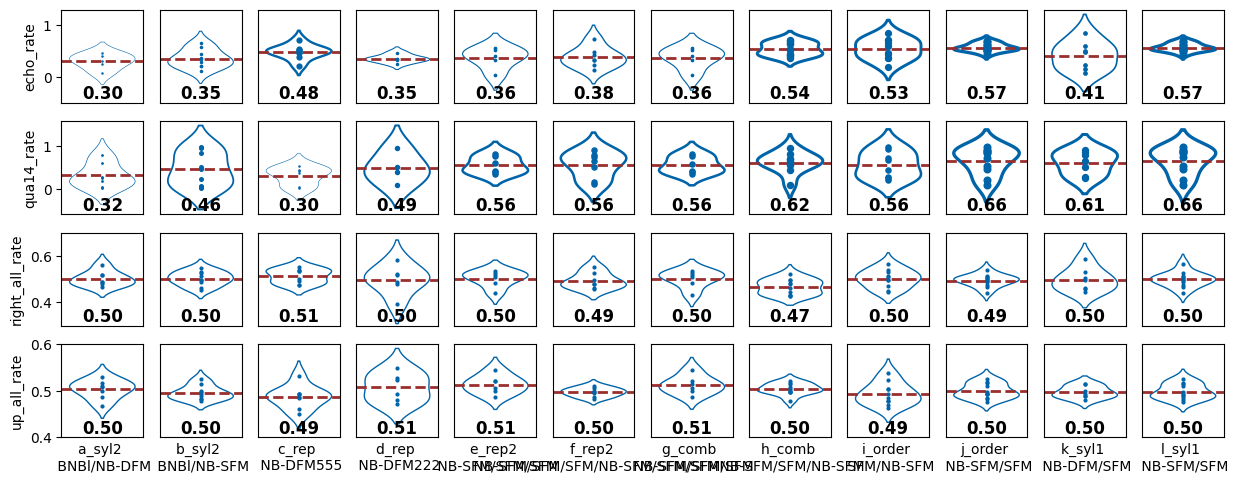

In [ ]:
# only use [right_arm] that in l0.5 p0.8
# qua3/(qua1+qua3)
# up_right/(up_right+down_left)
# TENDENCY analysis
param_list = ['echo_rate', 'qua14_rate', 'right_all_rate', 'up_all_rate']

plt.figure(108, figsize=(15, 7))
# p_i = 0
f_i = 0

for param in param_list:
    # p_i += 1
    average_param_list = []
    
    if param in ['qua14_rate']:
        ylim = [-0.6, 1.6]
        scaled_param_list = [0.51, 1.29, 0.4, 1.46, 1.84, 1.84, 1.84, 2.18, 1.84, 2.4, 2.12, 2.4]
    elif param == 'right_all_rate':
        ylim = [0.3, 0.7]
    elif param == 'up_all_rate':
        ylim = [0.4, 0.6]
    elif param == 'echo_rate':
        ylim = [-0.5, 1.3]
        scaled_param_list = [0.4, 0.77, 1.73, 0.77, 0.84, 0.99, 0.84, 2.18, 2.1, 2.4, 1.21, 2.4]


    # elif param == 'ave_f1':
    #     ylim = [-50, 130]
    #     scaled_param_list = [0.67, 1.76, 1.71, 0.4, 0.66, 0.87, 2.4, 1.8, 0.41, 0.4, 0.41, 2.3]
    # elif param == 'ave_f3':
    #     ylim = [-30, 80]
    #     scaled_param_list = [0.48, 0.97, 0.97, 0.51, 0.4, 0.41, 2.3, 2.4, 0.44, 0.58, 0.44, 1.64]
    # elif param == 'acc_ave_1':
    #     ylim = [-20, 50]
    #     scaled_param_list = [0.42, 0.85, 0.86, 0.93, 0.48, 0.79, 2.06, 2.4, 0.42, 1.26, 0.4, 2.14]
    # elif param == 'acc_ave_10':
    #     ylim = [-1, 2]
    # elif param == 'acc_ave_25':
    #     ylim = [-0.6, 1.5]
    #     scaled_param_list = [0.4, 0.84, 0.84, 1.29, 0.77, 0.99, 2.18, 2.4, 0.7, 1.73, 0.7, 2.25]
    # elif param == 'echo_rate':
    #     # ylim = [0, ]
    #     scaled_param_list = [2.18, 2.4, 2.4, 1.51, 1.18, 0.4, 1.18, 1.9, 0.9, 1.34, 0.9, 2.23]

    bodypart_list = ['right_arm']
    sti_i = -1        
    for bp in bodypart_list:
                
        for group in group_list:
            sti_list = all_data[all_data['group3'] == group]['stimuli'].unique()
        # print(group, sti_list)
        # bp_list = all_data[(all_data['group2'] == group)]['bodypart'].unique()
            sti_i = sti_i + 1
            for sti in sti_list:
                                   
                f_i += 1
                param_data = all_data[(all_data['group3'] == group) & (all_data['stimuli'] == sti) & (all_data['bodypart'] == bp)][param]
                if group == 'b_syl2' and param == 'qua14_rate':
                    param_data = [x for x in param_data if x > 0 and x < 1]
                else:
                    param_data = [x for x in param_data if x > 0.02 and x < 1]
                
                plt.subplot(5, 12, f_i)
                # sns.boxplot(param_data, fliersize=2, fill=False)#, showmeans=True, meanprops={'color': 'red'}
                # plt.boxplot(param_data, showmeans=True, meanline=True, meanprops={'color': 'red'})
                # sns.boxplot(param_data, fill=False, linewidth=0.5)
                plt.axhline(y=np.mean(param_data), color='#992E2D', linestyle='--', linewidth=2)
                # sns.violinplot(param_data, fill=False, color='#0064A9', linewidth=1, inner="point")
                if param == 'qua14_rate' or param == 'echo_rate':
                    sns.violinplot(param_data, fill=False, color='#0064A9', linewidth=scaled_param_list[sti_i], inner='point')
                else:
                    sns.violinplot(param_data, fill=False, color='#0064A9', linewidth=1, inner="point")
                # set xlim
                plt.ylim(ylim[0], ylim[1])
                # plt.ylim(0, 1)
                plt.xticks([])
                average_param = "{:.2f}".format(np.mean(param_data))
                average_param_list.append(float(average_param))
                if float(average_param) > 0:
                    plt.title(average_param, fontsize=12, fontweight='bold', y=-0.05)#
                # plt.xlabel(f'{group} \n {sti}')
                if ((group == 'a_syl2') and (sti == 'BNBl/NB-DFM')):
                    plt.ylabel(param)
                else:
                    plt.ylabel('')
                    plt.yticks([])

                if param == 'up_all_rate':
                    plt.xlabel(f'{group} \n {sti}')# rotation=45, fontsize=8
    # 将数据缩放到 0.4-2.4 之间
    param_data_max = np.max(average_param_list)
    param_data_min = np.min(average_param_list)
    average_param_list_scaled = (average_param_list - param_data_min) / (param_data_max - param_data_min)
    average_param_list_scaled = average_param_list_scaled * (2.4-0.4) + 0.4
    average_param_list_scaled = [float(format(x, '.2f')) for x in average_param_list_scaled]
    print(average_param_list_scaled)

plt.savefig('tendency_plot3.png', dpi=300, bbox_inches='tight') 
plt.savefig('tendency_plot3.eps', dpi=300, bbox_inches='tight')
plt.savefig('tendency_plot3.svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close() 